In [30]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns

In [45]:
df = pd.read_csv("../data/creditcard.csv")
print("The shape of the dataset is :", df.shape)
print(df[["Time", "V1", "V28", "Amount", "Class"]].info())
print(df[["Time", "V1", "V17", "Amount", "Class"]].describe())

The shape of the dataset is : (284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V28     284807 non-null  float64
 3   Amount  284807 non-null  float64
 4   Class   284807 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 10.9 MB
None
                Time            V1           V17         Amount          Class
count  284807.000000  2.848070e+05  2.848070e+05  284807.000000  284807.000000
mean    94813.859575  1.168375e-15 -3.772171e-16      88.349619       0.001727
std     47488.145955  1.958696e+00  8.493371e-01     250.120109       0.041527
min         0.000000 -5.640751e+01 -2.516280e+01       0.000000       0.000000
25%     54201.500000 -9.203734e-01 -4.837483e-01       5.600000       0.000000
50%     84692.000000  1.810880e-02 -6.567575e-02   

<Axes: >

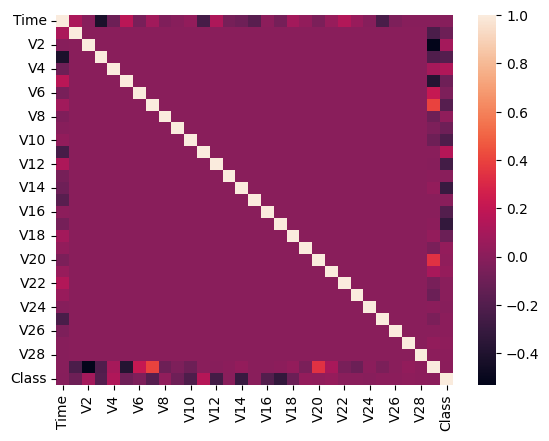

In [32]:
sns.heatmap(df.corr())

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Fraud vs Non-Fraud')

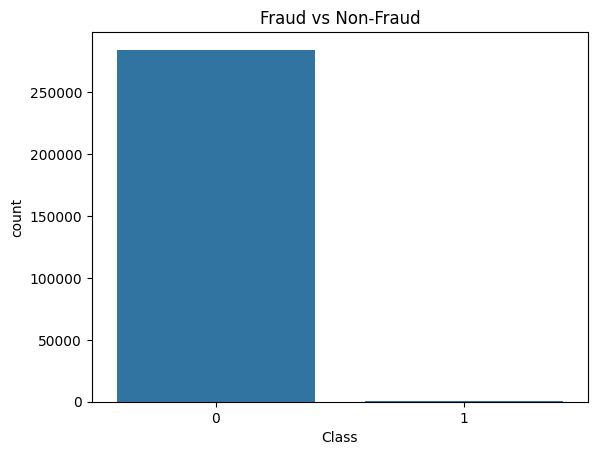

In [41]:
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True))
sns.countplot(x="Class", data=df)
plt.title("Fraud vs Non-Fraud")

Text(0.5, 1.0, 'Transaction Amount by Class')

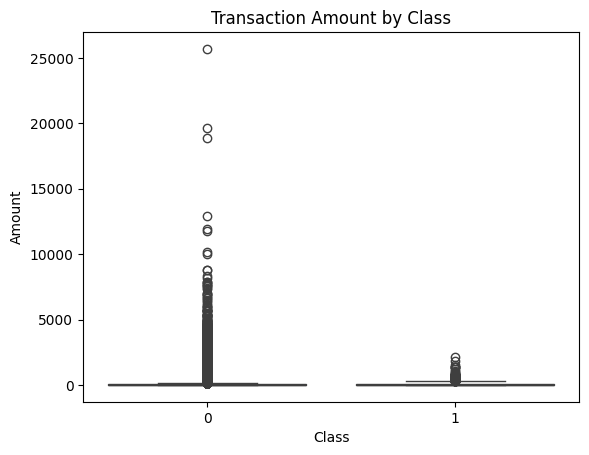

In [34]:
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Transaction Amount by Class")

(0.0, 200.0)

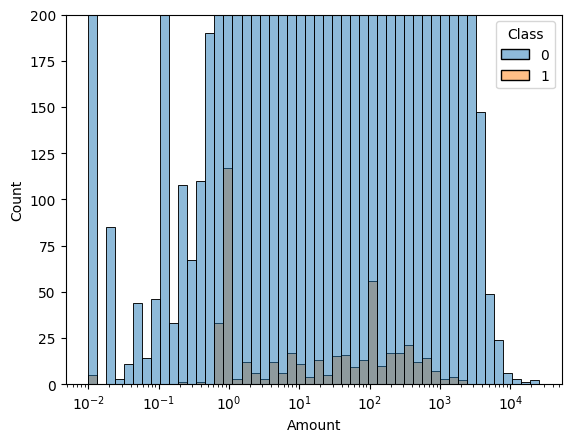

In [35]:
sns.histplot(data=df, x="Amount", hue="Class", bins=50, log_scale=True)
plt.ylim([0,200])

Text(0.5, 1.0, 'Fraud occurrences over time')

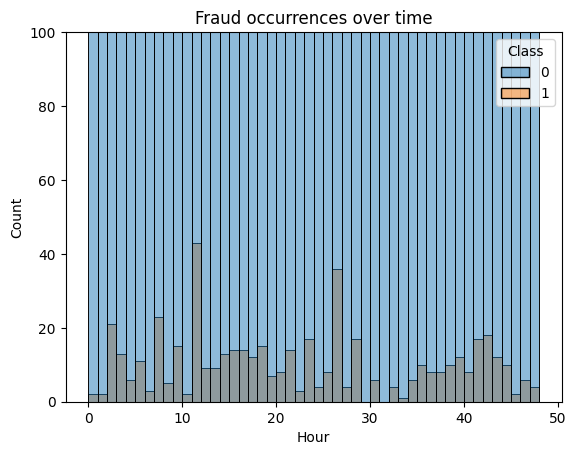

In [36]:
df["Hour"] = df["Time"] / 3600
sns.histplot(data=df, x="Hour", hue="Class", bins=48)
plt.ylim([0,100])
plt.title("Fraud occurrences over time")

<Axes: >

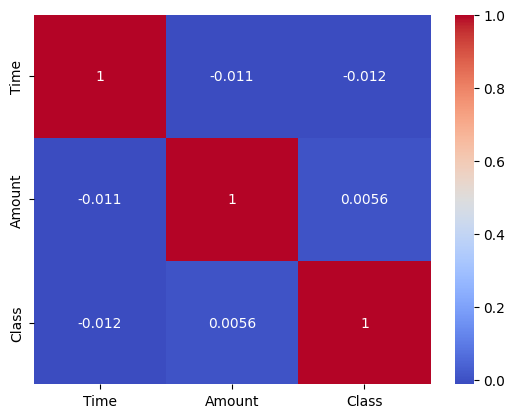

In [37]:
df[["Time","Amount","Class"]].corr()
sns.heatmap(df[["Time","Amount","Class"]].corr(), annot=True, cmap="coolwarm")

<Axes: xlabel='V28', ylabel='Density'>

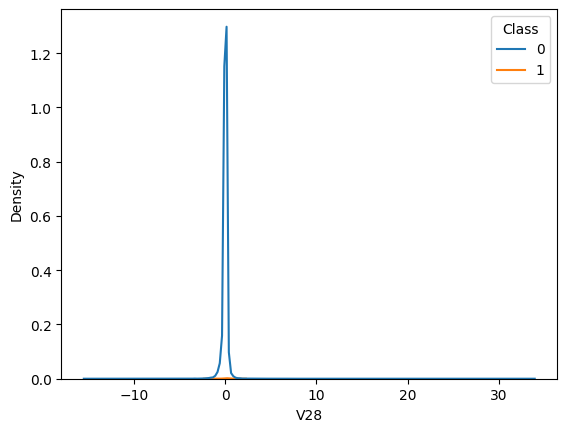

In [47]:
sns.kdeplot(data=df, x="V28", hue="Class")
#plt.xlim([-25,10])

In [39]:
df.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Hour
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022,26.343945
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321,22.429669


<Axes: xlabel='Class', ylabel='LogAmount'>

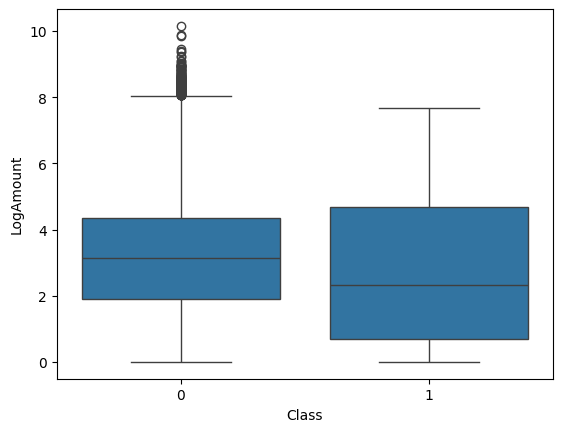

In [50]:
df["LogAmount"] = np.log1p(df["Amount"])
sns.boxplot(x="Class", y="LogAmount", data=df)

We notice strong asymetry in the dataset as expected, only 0.17% of fraud cases. A notable remark is that all frauds have amounts lesser than around 3000, they happen uniformly across time. Class is mostly correlated to variables V1-V18, while the rest seems quite decorrelated (at least linearly).

Non fraudulous amounts contain outliers that reach 25k, so we're gonna use the Log transformation of the amount to reduce such gaps.